In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [25]:
# Parametri per la simulazione
n_distanze = 50  # Numero di distanze tra scintillatori
n_muons = 100000  # Numero di muoni generati per simulazione
scintillator_width = 20.0  # Larghezza del rettangolo (in centimetri)
scintillator_height = 10.0  # Altezza del rettangolo (in centimetri)
efficiency_1 = 0.83  # Efficienza del primo scintillatore
efficiency_2 = 0.85  # Efficienza del secondo scintillatore
muon_rate_first_scintillator = 3.3# Numero di muoni al secondo che passano sul primo scintillatore (Hz)

distances = np.linspace(0, 80, n_distanze)

def generate_theta():
    """
    Genera un angolo theta secondo la distribuzione cosmica P(theta) = (4/pi) * cos^2(theta)
    utilizzando la funzione cumulativa inversa risolta con root_scalar.
    """
    # Genera un numero casuale uniforme tra 0 e 1
    num = np.random.uniform(0, 1)
    
    # Risolvi l'equazione cumulativa inversa per trovare theta
    theta = root_scalar(
        lambda x: (4 / np.pi) * ((x / 2) + (np.sin(2 * x) / 4)) - num,  # CDF cumulativa
        bracket=[0, np.pi / 2],  # Intervallo di theta
        method='brentq'  # Metodo di risoluzione
    )
    
    return theta.root  # Restituisce il valore di theta trovato

# Funzione teorica per la distribuzione di theta
def pdf_muon(theta):
    return (4 / np.pi) * np.cos(theta)**2

In [26]:
# Lista per salvare gli angoli theta generati
#theta_values = [generate_theta() for _ in range(n_muons)]
theta_values = []

# Rate di muoni rilevati da entrambi gli scintillatori (Hz)
muon_rates_both = []  #

for distance_between_scintillators in distances:
    detected_muons_both = 0

    for _ in range(n_muons):
        # Genera le coordinate x, y uniformemente distribuite sul primo scintillatore
        x1 = np.random.uniform(-scintillator_width / 2, scintillator_width / 2)
        y1 = np.random.uniform(-scintillator_height / 2, scintillator_height / 2)

        # Genera gli angoli theta e phi
        theta = generate_theta()
        phi = np.random.uniform(0, 2 * np.pi)
        # Salva l'angolo theta generato
        theta_values.append(theta)

        # Calcola la direzione del muone
        dx = np.sin(theta) * np.cos(phi)
        dy = np.sin(theta) * np.sin(phi)#
        dz = np.cos(theta)

        # Verifica se il muone è rilevato dal primo scintillatore
        if np.random.uniform(0, 1) <= efficiency_1:
            # Interpola la traiettoria per verificare se intercetta il secondo scintillatore
            t = distance_between_scintillators / dz  # Tempo per raggiungere il secondo scintillatore
            x2 = x1 + t * dx
            y2 = y1 + t * dy

            # Verifica se il muone intercetta il secondo scintillatore
            if (
                -scintillator_width / 2 <= x2 <= scintillator_width / 2
                and -scintillator_height / 2 <= y2 <= scintillator_height / 2
            ):
                # Verifica se il muone è rilevato dal secondo scintillatore
                if np.random.uniform(0, 1) <= efficiency_2:
                    detected_muons_both += 1

    # Calcola il rate di muoni rilevati da entrambi gli scintillatori
    muon_rates_both.append(detected_muons_both)

muon_rates_both = np.array(muon_rates_both)

100 bins from 0.0 to 1.571 rad
Bin width: 0.0157 radians


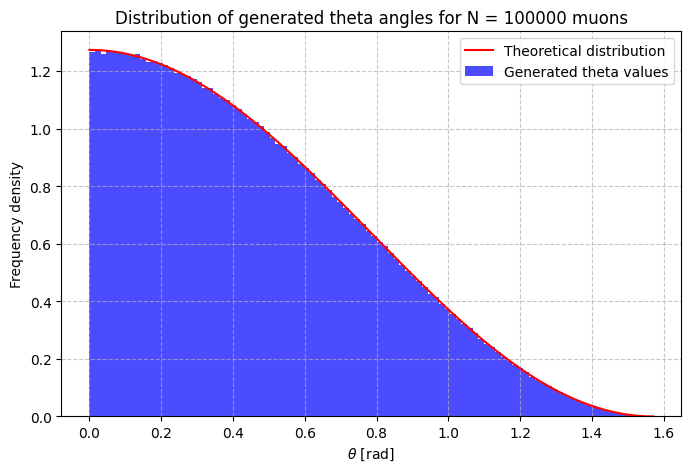

In [27]:
# Istogramma dei theta generati
theta_min = 0  # rad
theta_max = np.pi / 2  # rad
n_bins = 100  # Numero di bin
bin_width = (theta_max - theta_min) / n_bins  # Larghezza dei# bin
print('%d bins from %.1f to %.3f rad' % (n_bins, theta_min, theta_max))
print('Bin width: %.4f radians' % (bin_width))

# Calcolo dell'istogramma
hist, bin_edges = np.histogram(theta_values, bins=n_bins, density=True, range=(theta_min, theta_max))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calcolo dei centri dei bin

# Distribuzione teorica
theta = np.linspace(0, np.pi / 2, 1000)
theoretical_distribution = (4 / np.pi) * np.cos(theta)**2

# Grafico
plt.figure(figsize=(8, 5))
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]), color='blue', alpha=0.7, label='Generated theta values')
plt.plot(theta, theoretical_distribution, 'r-', label='Theoretical distribution')

# Correggi il titolo per mostrare il numero corretto di muoni
plt.title(f'Distribution of generated theta angles for N = {n_muons} muons')

plt.xlabel(r'$\theta$ [rad]')
plt.ylabel('Frequency density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('theta_distribution.png', dpi=300)  # Salva il grafico come immagine
plt.show()

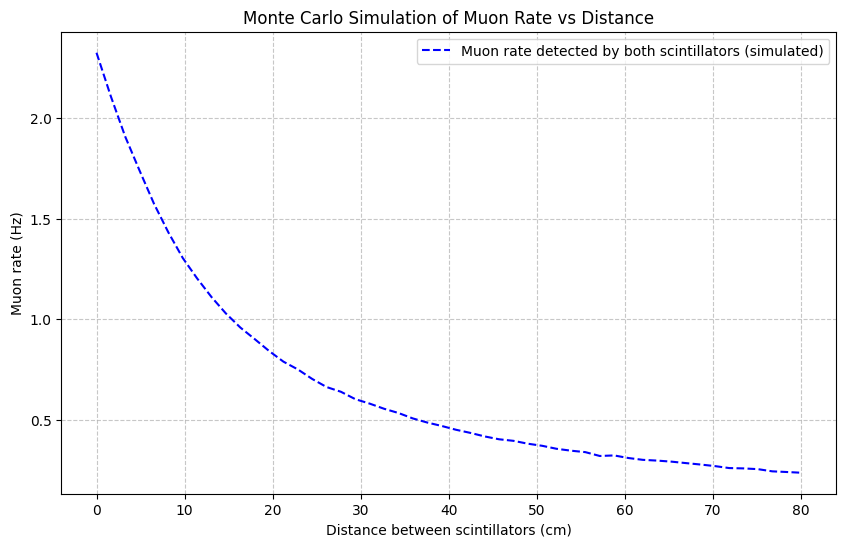

In [28]:
# Calcolo del rate di muoni rilevati da entrambi gli scintillatori
rate_both = (muon_rates_both / n_muons) * muon_rate_first_scintillator
    
# Grafico del rate di muoni rilevati da entrambi gli scintillatori in funzione della distanza
plt.figure(figsize=(10, 6))
plt.plot(distances, rate_both, '--', color='blue', label='Muon rate detected by both scintillators (simulated)')
plt.title('Monte Carlo Simulation of Muon Rate vs Distance')
plt.xlabel('Distance between scintillators (cm)')
plt.ylabel('Muon rate (Hz)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()